# Extract Frames from Video

In [1]:
#
##
import torchvision
#
## define video to extract frames from
var_path_video = "../dataset/video/act_49_41.mp4"
var_name = var_path_video.split("/")[-1].split(".")[0]
#
## define frames to extract
var_frame_index = list(range(0, 90, 1))
print(var_name, var_frame_index)

act_49_41 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]


In [2]:
#
## read video
data_frame, _, var_info = torchvision.io.read_video(var_path_video)
data_frame.shape

RuntimeError: File not found: ../dataset/video/act_49_41.mp4

In [ ]:
#
##
for var_i in var_frame_index:
    #
    data_image = data_frame[var_i].permute(2, 0, 1)
    #
    torchvision.io.write_jpeg(data_image, var_name + "_" + str(var_i) + ".jpg", 100)


# Visualize WiFi CSI

In [3]:
import os
import numpy as np
import pandas as pd
import scipy.io as scio
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, Normalizer

In [5]:
#        "data_x": "/local/data0/amir/PUBLIC_DATASET/wimans_dataset/wifi_csi/amp",  # directory of CSI amplitude files

##
var_path_mat = "/local/data0/amir/PUBLIC_DATASET/wimans_dataset/wifi_csi/mat/act_49_41.mat"
data_mat = scio.loadmat(var_path_mat)

In [6]:
#
##
var_length = data_mat["trace"].shape[0]
#
## 
data_csi_amp = []
for var_t in range(var_length):
    data_csi_amp.append(abs(data_mat["trace"][var_t][0][0][0][-1]))
#
data_csi_amp = np.array(data_csi_amp, dtype = np.float32)
#
print(data_csi_amp.shape)

(2757, 3, 3, 30)


(2757, 270)


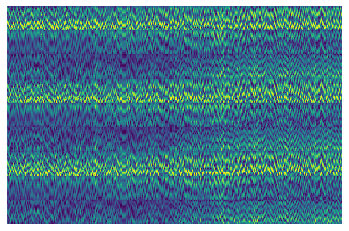

In [7]:
#
##
data_csi_show = abs(data_csi_amp.reshape(data_csi_amp.shape[0], -1))
print(data_csi_show.shape)
#
##
data_csi_show = np.transpose(data_csi_show)
var_x_encoder = MinMaxScaler() 
data_csi_show = var_x_encoder.fit_transform(data_csi_show)
data_csi_show = np.transpose(data_csi_show)
#
##
var_f, _ = plt.subplots(1, 1)
plt.axis("off")
var_image = plt.imshow(data_csi_show.T, interpolation = "none", aspect = "auto", cmap = "viridis")

In [8]:
var_name = var_path_mat.split("/")[-1].split(".")[0]
var_f.savefig(var_name + ".png", bbox_inches = "tight", pad_inches = 0, dpi = 600)

# Dataset Statistic

In [1]:
#
##
import pandas as pd
#
data_pd_y = pd.read_csv("../dataset/annotation.csv")

In [6]:
var_column = ["user_1_activity", "user_2_activity", "user_3_activity", "user_4_activity", "user_5_activity", "user_6_activity"]
for var_c in var_column:
    print(data_pd_y[var_c].value_counts())

nothing     528
walk        528
rotation    528
jump        528
wave        528
lie_down    528
pick_up     528
sit_down    528
stand_up    528
Name: user_1_activity, dtype: int64
walk        528
rotation    528
jump        528
wave        528
lie_down    528
pick_up     528
sit_down    528
stand_up    528
nothing     528
Name: user_2_activity, dtype: int64
rotation    528
jump        528
wave        528
lie_down    528
pick_up     528
sit_down    528
stand_up    528
nothing     528
walk        528
Name: user_3_activity, dtype: int64
jump        528
wave        528
lie_down    528
pick_up     528
sit_down    528
stand_up    528
nothing     528
walk        528
rotation    528
Name: user_4_activity, dtype: int64
wave        528
lie_down    528
pick_up     528
sit_down    528
stand_up    528
nothing     528
walk        528
rotation    528
jump        528
Name: user_5_activity, dtype: int64
nothing     528
walk        528
rotation    528
jump        528
wave        528
lie_down    528
pick

In [9]:
var_column = ["user_1_location", "user_2_location", "user_3_location", "user_4_location", "user_5_location", "user_6_location"]
for var_c in var_column:
    print(data_pd_y[var_c].value_counts().sort_index())

a    1296
b     864
c     864
d     864
e     864
Name: user_1_location, dtype: int64
a     864
b    1296
c     864
d     864
e     864
Name: user_2_location, dtype: int64
a     864
b     864
c    1296
d     864
e     864
Name: user_3_location, dtype: int64
a     864
b     864
c     864
d    1296
e     864
Name: user_4_location, dtype: int64
a     864
b     864
c     864
d     864
e    1296
Name: user_5_location, dtype: int64
a    1134
b    1026
c     864
d     864
e     864
Name: user_6_location, dtype: int64


## Packet Loss

In [57]:
#
##
import os
import numpy as np
import pandas as pd
#
##
def load_data_y(var_path_data_y,
                var_environment = None, 
                var_wifi_band = None, 
                var_num_users = None):
    #
    ##
    data_pd_y = pd.read_csv(var_path_data_y, dtype = str)
    #
    if var_environment is not None:
        data_pd_y = data_pd_y[data_pd_y["environment"].isin(var_environment)]
    #
    if var_wifi_band is not None:
        data_pd_y = data_pd_y[data_pd_y["wifi_band"].isin(var_wifi_band)]
    #
    if var_num_users is not None:
        data_pd_y = data_pd_y[data_pd_y["number_of_users"].isin(var_num_users)]
    #
    return data_pd_y

#
##
def summarize_packet_loss(var_dir_amp, data_pd_y):
    #
    ##
    var_length_x = []
    #
    for var_c, var_label in enumerate(list(data_pd_y["label"])):
        #
        data_x = np.load(os.path.join(var_dir_amp, var_label + ".npy"))
        #
        var_length_x.append(data_x.shape[0])
    #
    var_length_x = np.array(var_length_x)
    print(np.average(var_length_x))
    #
    var_loss_rate = (3000 - var_length_x) / 3000 * 100
    var_avg = np.average(var_loss_rate)
    var_std = np.std(var_loss_rate)
    #
    return var_avg, var_std

In [58]:
#
##
data_pd_y = load_data_y("../dataset/annotation.csv", var_wifi_band = ["2.4"])
var_path_x = "../dataset/wifi_csi/amp"
var_avg, var_std = summarize_packet_loss(var_path_x, data_pd_y)
#
print("Avg: %.2f - Std: %.2f "%(var_avg, var_std))

2864.393762183236
Avg: 4.52 - Std: 2.75 


In [59]:
#
##
data_pd_y = load_data_y("../dataset/annotation.csv", var_wifi_band = ["5"])
var_path_x = "../dataset/wifi_csi/amp"
var_avg, var_std = summarize_packet_loss(var_path_x, data_pd_y)
#
print("Avg: %.2f - Std: %.2f "%(var_avg, var_std))

2930.7210703526493
Avg: 2.31 - Std: 1.57 


# Three Person Inside the room, Versus Two person Versus, One Person

In [10]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.svm import SVC
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import argparse
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm # Use tqdm.notebook for notebooks
import torchvision.transforms as transforms
import pandas as pd
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA # Import PCA
import os
"""
[file]          preset.py
[description]   default settings of WiFi-based models
"""
#
##
preset = {
    #
    ## define model
    "wandb_name": "test",
    "model": "DETR",                                    # "ST-RF", "MLP", "LSTM", "CNN-1D", "CNN-2D", "CLSTM", "ABLSTM", "THAT",
                                                              # "THAT_COUNT", "THAT_ENCODER", THAT_COUNT_CONSTRAINED, THAT_MULTI_HEAD DETR
                                                            #JOINT_DETR
    # "model": "MLP",
    ## define task
    "task": "activity",                                 # "identity", "activity", "location"
    #
    ## number of repeated experiments
    "repeat": 8,
    ## path of data
    "path": {
        "data_x": "/local/data0/amir/PUBLIC_DATASET/wimans_dataset/wifi_csi/amp",  # directory of CSI amplitude files
        "data_y": "/local/data0/amir/PUBLIC_DATASET/wimans_dataset/annotation.csv",  # path of annotation file
        "save": "results/result.json"                           # path to save results
    },
        #
    ## data selection for experiments
    "data": {
        "num_users": ["0","1", "2", "3", "4", "5"] ,   # select number(s) of users, (e.g., ["0", "1"], ["2", "3", "4", "5"])
        "wifi_band": ["5"],                           # select WiFi band(s) (e.g., ["2.4"], ["5"], ["2.4", "5"])
        "environment": ["empty_room"],                   # select environment(s) (e.g., ["classroom"], ["meeting_room"], ["empty_room"])
        "length": 3000,                                 # default length of CSI
    },
    #
    ## hyperparameters of models
    "nn": {
        "lr": 1e-3,                                     # learning rate
        "epoch": 200,                                   # number of epochs
        "batch_size": 128,                              # batch size
        "threshold": 0.5,                               # threshold to binarize sigmoid outputs
    },
    #
    ## encoding of activities and locations
    "encoding": {
        "activity": {                                   # encoding of different activities
            "nan":      [0, 0, 0, 0, 0, 0, 0, 0, 0],
            "nothing":  [1, 0, 0, 0, 0, 0, 0, 0, 0],
            "walk":     [0, 1, 0, 0, 0, 0, 0, 0, 0],
            "rotation": [0, 0, 1, 0, 0, 0, 0, 0, 0],
            "jump":     [0, 0, 0, 1, 0, 0, 0, 0, 0],
            "wave":     [0, 0, 0, 0, 1, 0, 0, 0, 0],
            "lie_down": [0, 0, 0, 0, 0, 1, 0, 0, 0],
            "pick_up":  [0, 0, 0, 0, 0, 0, 1, 0, 0],
            "sit_down": [0, 0, 0, 0, 0, 0, 0, 1, 0],
            "stand_up": [0, 0, 0, 0, 0, 0, 0, 0, 1],
        },
        "location": {                                   # encoding of different locations
            "nan":  [0, 0, 0, 0, 0],
            "a":    [1, 0, 0, 0, 0],
            "b":    [0, 1, 0, 0, 0],
            "c":    [0, 0, 1, 0, 0],
            "d":    [0, 0, 0, 1, 0],
            "e":    [0, 0, 0, 0, 1],
        },
    },
}


In [9]:
"""
[file]          load_data.py
[description]   load annotation file and CSI amplitude, and encode labels
"""
def load_data_y(var_path_data_y,
                var_environment = None, 
                var_wifi_band = None, 
                var_num_users = None):
    """
    [description]
    : load annotation file (*.csv) as a pandas dataframe
    : according to selected environment(s), WiFi band(s), and number(s) of users
    [parameter]
    : var_path_data_y: string, path of annotation file
    : var_environment: list, selected environment(s), e.g., ["classroom"]
    : var_wifi_band: list, selected WiFi band(s), e.g., ["2.4"]
    : var_num_users: list, selected number(s) of users, e.g., ["0", "1", "2"]
    [return]
    : data_pd_y: pandas dataframe, labels of selected data
    """
    #
    ##
    data_pd_y = pd.read_csv(var_path_data_y, dtype = str)
    #
    if var_environment is not None:
        data_pd_y = data_pd_y[data_pd_y["environment"].isin(var_environment)]
    #
    if var_wifi_band is not None:
        data_pd_y = data_pd_y[data_pd_y["wifi_band"].isin(var_wifi_band)]
    #
    if var_num_users is not None:
        data_pd_y = data_pd_y[data_pd_y["number_of_users"].isin(var_num_users)]
    #
    return data_pd_y

#
##
def load_data_x(var_path_data_x, 
                var_label_list):
    """
    [description]
    : load CSI amplitude (*.npy)
    : according to a label list of selected data
    [parameter]
    : var_path_data_x: string, directory of CSI amplitude files
    : var_label_list: list, selected labels
    [return]
    : data_x: numpy array, CSI amplitude
    """
    #
    ##
    var_path_list = [os.path.join(var_path_data_x, var_label + ".npy") for var_label in var_label_list]
    #
    data_x = []
    #
    for var_path in var_path_list:
        #
        data_csi = np.load(var_path)
        #
        var_pad_length = preset["data"]["length"] - data_csi.shape[0]
        #
        data_csi_pad = np.pad(data_csi, ((var_pad_length, 0), (0, 0), (0, 0), (0, 0)))
        #
        data_x.append(data_csi_pad)
    #
    data_x = np.array(data_x)
    #
    return data_x

#
##
def encode_data_y(data_pd_y, 
                  var_task):
    """
    [description]
    : encode labels according to specific task
    [parameter]
    : data_pd_y: pandas dataframe, labels of different tasks
    : var_task: string, indicate task
    [return]
    : data_y: numpy array, label encoding of task
    """
    #
    ##
    if var_task == "identity":
        #
        data_y = encode_identity(data_pd_y)
    #
    elif var_task == "activity":
        #
        data_y = encode_activity(data_pd_y, preset["encoding"]["activity"])
    #
    elif var_task == "location":
        #
        data_y = encode_location(data_pd_y, preset["encoding"]["location"])
    #
    return data_y

#
##
def encode_identity(data_pd_y):
    """
    [description]
    : encode identity labels in a pandas dataframe
    [parameter]
    : data_pd_y: pandas dataframe, labels of different tasks
    [return]
    : data_identity_onehot_y: numpy array, onehot encoding for identity labels
    """
    #
    ##
    data_location_pd_y = data_pd_y[["user_1_location", "user_2_location", 
                                    "user_3_location", "user_4_location", 
                                    "user_5_location", "user_6_location"]]
    # 
    data_identity_y = data_location_pd_y.to_numpy(copy = True).astype(str)
    #
    data_identity_y[data_identity_y != "nan"] = 1
    data_identity_y[data_identity_y == "nan"] = 0
    #
    data_identity_onehot_y = data_identity_y.astype("int8")
    #
    return data_identity_onehot_y

#
##
def encode_activity(data_pd_y, 
                    var_encoding):
    """
    [description]
    : encode activity labels in a pandas dataframe
    [parameter]
    : data_pd_y: pandas dataframe, labels of different tasks
    : var_encoding: dict, encoding of different activities
    [return]
    : data_activity_onehot_y: numpy array, onehot encoding for activity labels
    """
    #
    ##
    data_activity_pd_y = data_pd_y[["user_1_activity", "user_2_activity", 
                                    "user_3_activity", "user_4_activity", 
                                    "user_5_activity", "user_6_activity"]]
    #
    data_activity_y = data_activity_pd_y.to_numpy(copy = True).astype(str)
    #
    data_activity_onehot_y = np.array([[var_encoding[var_y] for var_y in var_sample] for var_sample in data_activity_y])
    #
    return data_activity_onehot_y

#
##
def encode_location(data_pd_y, 
                    var_encoding):
    """
    [description]
    : encode location labels in a pandas dataframe
    [parameter]
    : data_pd_y: pandas dataframe, labels of different tasks
    : var_encoding: dict, encoding of different locations
    [return]
    : data_location_onehot_y: numpy array, onehot encoding for location labels
    """
    #
    ##
    data_location_pd_y = data_pd_y[["user_1_location", "user_2_location", 
                                    "user_3_location", "user_4_location", 
                                    "user_5_location", "user_6_location"]]
    #
    data_location_y = data_location_pd_y.to_numpy(copy = True).astype(str)
    #
    data_location_onehot_y = np.array([[var_encoding[var_y] for var_y in var_sample] for var_sample in data_location_y])
    #
    return data_location_onehot_y

#
##
def test_load_data_x():
    """
    [description]
    : test load_data_x() function
    """
    #
    ##
    data_pd_y = load_data_y(preset["path"]["data_y"],
                            var_environment = ["meeting_room"], 
                            var_wifi_band = ["2.4"], 
                            var_num_users = None)
    #
    var_label_list = data_pd_y["label"].to_list()
    #
    data_x = load_data_x(preset["path"]["data_x"], var_label_list)
    #
    print(data_x.shape)

#
##
def test_encode_identity():
    """
    [description]
    : test encode_identity() function
    """
    #
    ##
    data_pd_y = pd.read_csv(preset["path"]["data_y"], dtype = str)
    #
    data_identity_onehot_y = encode_identity(data_pd_y)
    #
    print(data_identity_onehot_y.shape)
    #
    print(data_identity_onehot_y[2000])

#
##
def test_encode_activity():
    """
    [description]
    : test encode_activity() function
    """
    #
    ##
    data_pd_y = pd.read_csv(preset["path"]["data_y"], dtype = str)
    #
    data_activity_onehot_y = encode_activity(data_pd_y, preset["encoding"]["activity"])
    #
    print(data_activity_onehot_y.shape)
    #
    print(data_activity_onehot_y[1560])

#
##
def test_encode_location():
    """
    [description]
    : test encode_location() function
    """
    #
    ##
    data_pd_y = pd.read_csv(preset["path"]["data_y"], dtype = str)
    #
    data_location_onehot_y = encode_location(data_pd_y, preset["encoding"]["location"])
    #
    print(data_location_onehot_y.shape)
    #
    print(data_location_onehot_y[1560])

In [11]:
from sklearn.model_selection import train_test_split

data_pd_y = load_data_y(preset["path"]["data_y"],
                        var_environment = preset["data"]["environment"], 
                        var_wifi_band = preset["data"]["wifi_band"], 
                        var_num_users = preset["data"]["num_users"])
#
var_label_list = data_pd_y["label"].to_list()
#
## load CSI amplitude
data_x = load_data_x(preset["path"]["data_x"], var_label_list)
#
## encode labels
var_task = preset['task']
data_y = encode_data_y(data_pd_y, var_task)
#


In [16]:
y = data_y.sum(axis=1)


In [17]:
y

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [18]:
data_x.shape



(1881, 3000, 3, 3, 30)

## Compare CSI for Different Target Activity Combinations

This section visualizes and compares CSI data for samples corresponding to three different aggregated activity profiles. The `y` variable used for matching is `data_y.sum(axis=1)`, representing the sum of one-hot encoded activities across all users for each sample. The CSI data is plotted along the time domain.

We define three target profiles:
- **y_1**: Target profile where only the first activity class is active (e.g., sum of activities is `[1,0,0,...,0]`).
- **y_2**: Target profile where only the second activity class is active (e.g., sum of activities is `[0,1,0,...,0]`).
- **y_3**: Target profile where both the first and second activity classes are simultaneously active (e.g., sum of activities is `[1,1,...,0]`).

For each target, we search for a sample `i` such that `y[i]` matches the target. If found, we plot `data_x[i, :, 0, 0, 0]`. This corresponds to visualizing the CSI data across all 3000 time steps, for the first receive antenna, first transmit antenna, and first subcarrier (assuming these are the interpretations of the indices `0,0,0` in the dimensions `(3,3,30)` after the time dimension).

In [75]:
found_csi_data


{'y_1': array([ 0.      ,  0.      ,  0.      , ..., 42.379242, 43.829212,
        43.011627], dtype=float32),
 'y_2': array([ 0.      ,  0.      ,  0.      , ..., 18.027756, 18.35756 ,
        17.691807], dtype=float32),
 'y_3': array([ 0.      ,  0.      ,  0.      , ..., 38.587563, 36.40055 ,
        41.761227], dtype=float32)}

Shape of data_x: (1881, 3000, 3, 3, 30)
Shape of y (summed activities): (1881, 9)
Number of activity classes: 9
Target y_1: [0, 2, 1, 0, 0, 0, 0, 0, 0]
Target y_2: [0, 1, 1, 0, 0, 0, 0, 0, 0]
Found and filtered sample for target_1 at index 937. CSI stream shape: (3000,)
Found and filtered sample for target_2 at index 595. CSI stream shape: (3000,)


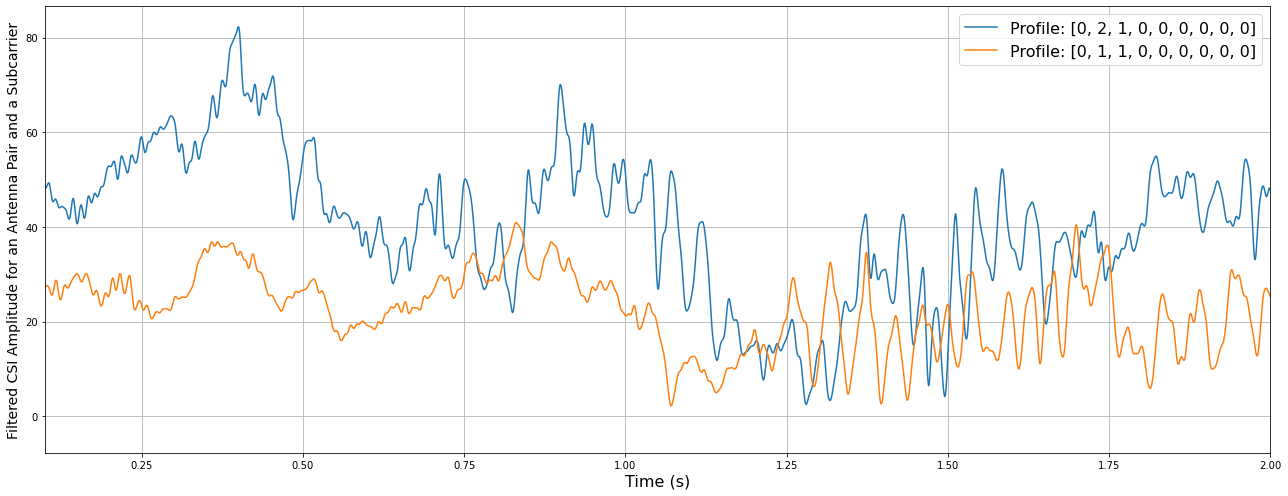

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

# Ensure y (data_y.sum(axis=1)) and data_x are available from previous cells.
# y shape: (num_samples, num_activity_classes)
# data_x shape: (num_samples, 3000, 3, 3, 30)

print(f"Shape of data_x: {data_x.shape}")
print(f"Shape of y (summed activities): {y.shape}")

num_activity_classes = y.shape[1]
print(f"Number of activity classes: {num_activity_classes}")

# Define target y vectors
y_target_1 = np.array([0, 2, 1, 0, 0, 0, 0, 0, 0])
y_target_2 = np.array([0, 1, 1, 0, 0, 0, 0, 0, 0])

print(f"Target y_1: {y_target_1.tolist()}")
print(f"Target y_2: {y_target_2.tolist()}")

targets_to_find = {
    'target_1': y_target_1,
    'target_2': y_target_2,
}

found_csi_data = {}
found_indices = {}

# Filter parameters (similar to cell 37 / id 91fb2fa0)
sampling_rate = 1000  # Hz (assuming, adjust if known)
cutoff_frequency = 100  # Hz
nyquist_frequency = 0.5 * sampling_rate
normalized_cutoff = cutoff_frequency / nyquist_frequency
filter_order = 4  # Order of the Butterworth filter

# Design the Butterworth low-pass filter
b, a = butter(filter_order, normalized_cutoff, btype='low', analog=False)

for name, target_profile in targets_to_find.items():
    # Find indices where y matches the target_profile exactly
    match_indices = np.where(np.all(y == target_profile, axis=1))[0]
    if len(match_indices) > 0:
        idx = match_indices[0]  # Take the first match
        found_indices[name] = idx

        # Extract CSI: data_x[idx, :, 0, 0, 0]
        csi_stream = data_x[idx, :, 0, 0, 0]
        
        # Apply the low-pass filter
        filtered_csi_stream = filtfilt(b, a, csi_stream)
        found_csi_data[name] = filtered_csi_stream # Store filtered data
        print(f"Found and filtered sample for {name} at index {idx}. CSI stream shape: {filtered_csi_stream.shape}")
    else:
        print(f"Warning: No sample found for {name} with profile {target_profile.tolist()}")

plt.figure(figsize=(18, 7))
plotted_anything = False
for name, filtered_csi_stream in found_csi_data.items(): # Iterate over filtered data
    plt.plot(np.arange(0,len(filtered_csi_stream))/1000, filtered_csi_stream, label=f'Profile: {targets_to_find[name].tolist()}')
    plotted_anything = True

if plotted_anything:
    # plt.title(f'Comparison of Low-Pass Filtered CSI Time Series (Cutoff: {cutoff_frequency} Hz)', fontsize=16) # Increased title font size
    plt.xlabel('Time (s)', fontsize=16) # Increased x-axis label font size
    plt.ylabel('Filtered CSI Amplitude for an Antenna Pair and a Subcarrier', fontsize=14) # Increased y-axis label font size
    plt.legend(loc='best', fontsize=16) # Increased legend font size
    plt.xlim(100/1000, 2000/1000)
    plt.grid(True)
else:
    plt.text(0.5, 0.5, 'No data to plot. Check console output for warnings.', \
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, wrap=True, fontsize=14)
plt.tight_layout()
plt.savefig("csi_comparison.pdf", bbox_inches='tight')
plt.show()

## Frequency Spectrum of Received CSI Signals

This section visualizes the frequency spectrum of the first 15 CSI samples. For each sample, the time-domain signal `data_x[sample_idx, :, 0, 0, 0]` is transformed using a Fast Fourier Transform (FFT). The plot shows the magnitude of the positive frequency components.

Shape of data_x: (1881, 3000, 3, 3, 30)


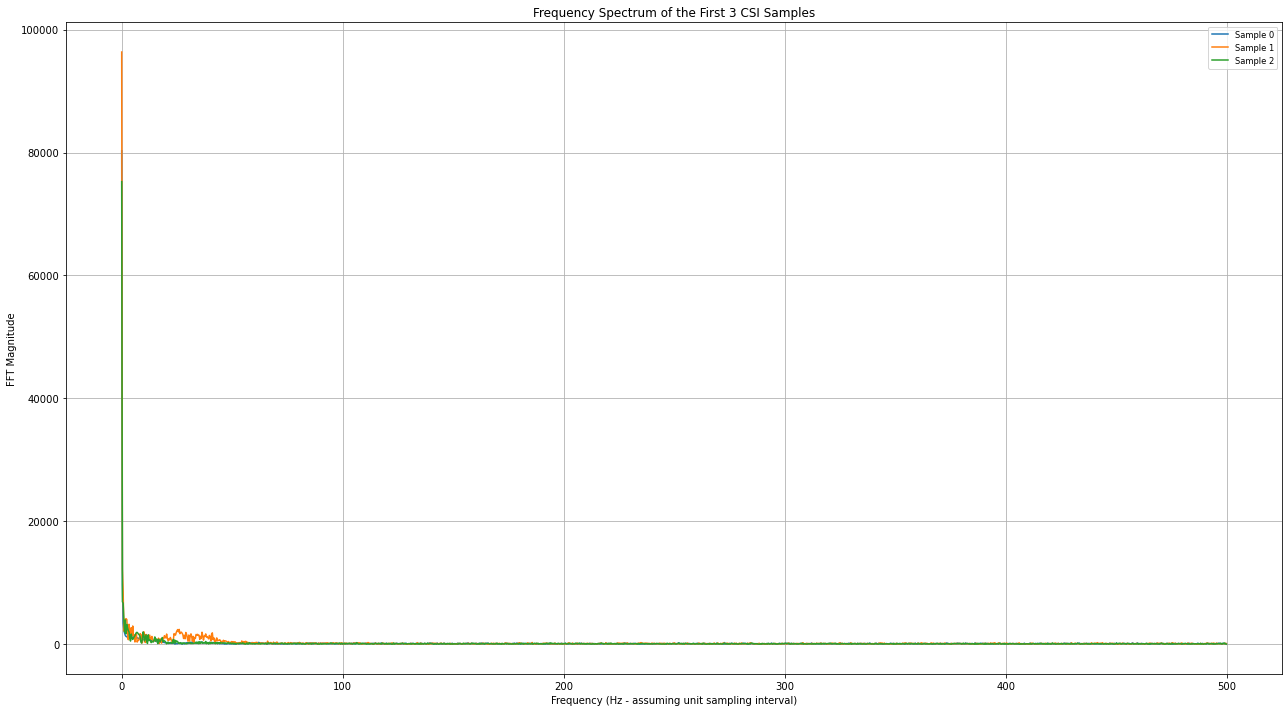

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure data_x is available from previous cells.
# data_x shape: (num_samples, 3000, 3, 3, 30)

if 'data_x' not in locals():
    print("Error: data_x is not defined. Please ensure it is loaded in a previous cell.")
else:
    print(f"Shape of data_x: {data_x.shape}")
    num_samples_to_plot = 3
    if data_x.shape[0] < num_samples_to_plot:
        print(f"Warning: Requested {num_samples_to_plot} samples, but data_x only has {data_x.shape[0]} samples. Plotting all available samples.")
        num_samples_to_plot = data_x.shape[0]

    if num_samples_to_plot > 0:
        time_series_length = data_x.shape[1] # Should be 3000
        sampling_rate = 1000 # Assuming unit time steps for frequency axis calculation, can be adjusted if actual rate is known
        
        plt.figure(figsize=(18, 10))
        
        for i in range(num_samples_to_plot):
            # Extract the time-domain signal for the i-th sample
            # Using slice [i, :, 0, 0, 0] as per previous examples
            signal = data_x[i, :, 0, 0, 0]
            
            # Compute FFT
            fft_result = np.fft.fft(signal)
            fft_magnitude = np.abs(fft_result)
            
            # Compute frequencies for the x-axis
            # We only need to plot the first half (positive frequencies)
            frequencies = np.fft.fftfreq(time_series_length, d=1/sampling_rate)
            positive_frequencies = frequencies[:time_series_length // 2]
            positive_fft_magnitude = fft_magnitude[:time_series_length // 2]
            
            plt.plot(positive_frequencies, positive_fft_magnitude, label=f'Sample {i}')
        
        plt.title(f'Frequency Spectrum of the First {num_samples_to_plot} CSI Samples')
        plt.xlabel('Frequency (Hz - assuming unit sampling interval)')
        plt.ylabel('FFT Magnitude')
        plt.legend(loc='upper right', fontsize='small')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No samples available in data_x to plot.")

## Low-Pass Filtering of CSI Signals and Time-Domain Visualization

This section applies a low-pass filter to the first 15 CSI samples and visualizes the filtered signals in the time domain. The sampling frequency is assumed to be 1000 Hz. The filter is designed to remove frequency components above 100 Hz.

A Butterworth low-pass filter is used for this purpose. The `filtfilt` function is used to apply the filter, which performs zero-phase filtering by processing the signal in both forward and reverse directions.

In [45]:
match_indices


array([798, 807, 816, 825, 834])

In [71]:
sum(y == np.array([[0 ,1 ,1 ,0 ,1 ,0 ,0 ,0, 0]]))

array([1476,  324,  324, 1476,  324, 1476, 1476, 1476, 1476])

In [72]:
for i in range(800, 1200):
    print(y[i])


[0 0 0 1 0 0 0 0 1]
[1 0 0 0 1 0 0 0 0]
[0 1 0 0 0 1 0 0 0]
[0 0 1 0 0 0 1 0 0]
[0 0 0 1 0 0 0 1 0]
[0 0 0 0 1 0 0 0 1]
[1 0 0 0 0 1 0 0 0]
[0 1 0 0 0 0 1 0 0]
[0 0 1 0 0 0 0 1 0]
[0 0 0 1 0 0 0 0 1]
[1 0 0 0 1 0 0 0 0]
[0 1 0 0 0 1 0 0 0]
[0 0 1 0 0 0 1 0 0]
[0 0 0 1 0 0 0 1 0]
[0 0 0 0 1 0 0 0 1]
[1 0 0 0 0 1 0 0 0]
[0 1 0 0 0 0 1 0 0]
[0 0 1 0 0 0 0 1 0]
[0 0 0 1 0 0 0 0 1]
[1 0 0 0 1 0 0 0 0]
[0 1 0 0 0 1 0 0 0]
[0 0 1 0 0 0 1 0 0]
[0 0 0 1 0 0 0 1 0]
[0 0 0 0 1 0 0 0 1]
[1 0 0 0 0 1 0 0 0]
[0 1 0 0 0 0 1 0 0]
[0 0 1 0 0 0 0 1 0]
[0 0 0 1 0 0 0 0 1]
[1 0 0 0 1 0 0 0 0]
[0 1 0 0 0 1 0 0 0]
[0 0 1 0 0 0 1 0 0]
[0 0 0 1 0 0 0 1 0]
[0 0 0 0 1 0 0 0 1]
[1 0 0 0 0 1 0 0 0]
[0 1 0 0 0 0 1 0 0]
[0 0 1 0 0 0 0 1 0]
[0 0 0 1 0 0 0 0 1]
[1 0 1 0 0 0 0 0 0]
[0 1 0 1 0 0 0 0 0]
[0 0 1 0 1 0 0 0 0]
[0 0 0 1 0 1 0 0 0]
[0 0 0 0 1 0 1 0 0]
[0 0 0 0 0 1 0 1 0]
[0 0 0 0 0 0 1 0 1]
[1 0 0 0 0 0 0 1 0]
[0 1 0 0 0 0 0 0 1]
[1 0 1 0 0 0 0 0 0]
[0 1 0 1 0 0 0 0 0]
[0 0 1 0 1 0 0 0 0]
[0 0 0 1 0 1 0 0 0]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

# Ensure y (data_y.sum(axis=1)) and data_x are available from previous cells.
# y shape: (num_samples, num_activity_classes)
# data_x shape: (num_samples, 3000, 3, 3, 30)

print(f"Shape of data_x: {data_x.shape}")
print(f"Shape of y (summed activities): {y.shape}")

num_activity_classes = y.shape[1]
print(f"Number of activity classes: {num_activity_classes}")

# Define target y vectors
y_target_1 = np.array([0, 2, 1, 0, 0, 0, 0, 0, 0])
y_target_2 = np.array([0, 1, 1, 0, 0, 0, 0, 0, 0])

print(f"Target y_1: {y_target_1.tolist()}")
print(f"Target y_2: {y_target_2.tolist()}")

targets_to_find = {
    'target_1': y_target_1,
    'target_2': y_target_2,
}

found_csi_data = {}
found_indices = {}

# Filter parameters (similar to cell 37 / id 91fb2fa0)
sampling_rate = 1000  # Hz (assuming, adjust if known)
cutoff_frequency = 100  # Hz
nyquist_frequency = 0.5 * sampling_rate
normalized_cutoff = cutoff_frequency / nyquist_frequency
filter_order = 4  # Order of the Butterworth filter

# Design the Butterworth low-pass filter
b, a = butter(filter_order, normalized_cutoff, btype='low', analog=False)

for name, target_profile in targets_to_find.items():
    # Find indices where y matches the target_profile exactly
    match_indices = np.where(np.all(y == target_profile, axis=1))[0]
    if len(match_indices) > 0:
        idx = match_indices[0]  # Take the first match
        found_indices[name] = idx

        # Extract CSI: data_x[idx, :, 0, 0, 0]
        csi_stream = data_x[idx, :, 0, 0, 0]
        
        # Apply the low-pass filter
        filtered_csi_stream = filtfilt(b, a, csi_stream)
        found_csi_data[name] = filtered_csi_stream # Store filtered data
        print(f"Found and filtered sample for {name} at index {idx}. CSI stream shape: {filtered_csi_stream.shape}")
    else:
        print(f"Warning: No sample found for {name} with profile {target_profile.tolist()}")

plt.figure(figsize=(18, 7))
plotted_anything = False
for name, filtered_csi_stream in found_csi_data.items(): # Iterate over filtered data
    plt.plot(filtered_csi_stream, label=f'Filtered CSI for {name} (sample idx {found_indices[name]}) - Profile: {targets_to_find[name].tolist()}')
    plotted_anything = True

if plotted_anything:
    plt.title(f'Comparison of Low-Pass Filtered CSI Time Series (Cutoff: {cutoff_frequency} Hz)')
    plt.xlabel('Time Step (0-2999)')
    plt.ylabel('Filtered CSI Amplitude (data_x[idx, :, 0, 0, 0])')
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
else:
    plt.text(0.5, 0.5, 'No data to plot. Check console output for warnings.', \
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, wrap=True)
plt.tight_layout()
plt.show()

Shape of data_x: (1881, 3000, 3, 3, 30)


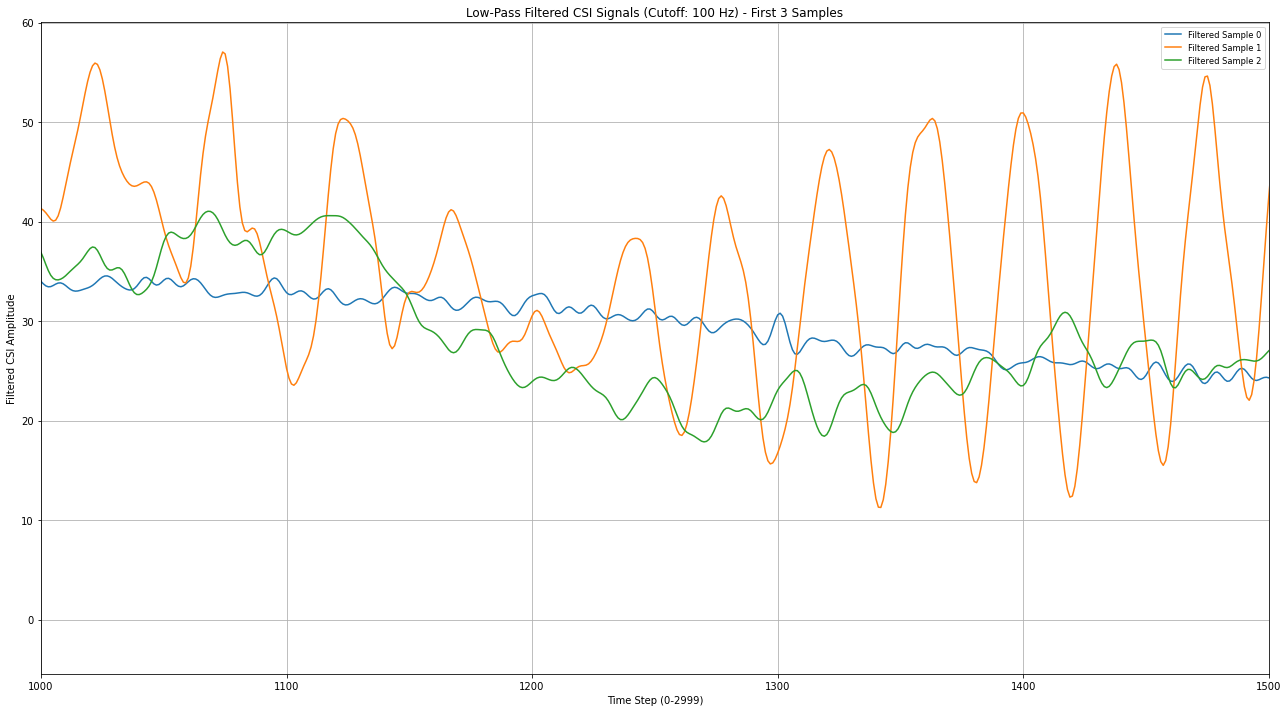

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt


# Ensure data_x is available from previous cells.
# data_x shape: (num_samples, 3000, 3, 3, 30)

if 'data_x' not in locals():
    print("Error: data_x is not defined. Please ensure it is loaded in a previous cell.")
else:
    print(f"Shape of data_x: {data_x.shape}")
    num_samples_to_plot = 3
    if data_x.shape[0] < num_samples_to_plot:
        print(f"Warning: Requested {num_samples_to_plot} samples, but data_x only has {data_x.shape[0]} samples. Plotting all available samples.")
        num_samples_to_plot = data_x.shape[0]

    if num_samples_to_plot > 0:
        # Filter parameters
        sampling_rate = 1000  # Hz
        cutoff_frequency = 100  # Hz
        nyquist_frequency = 0.5 * sampling_rate
        normalized_cutoff = cutoff_frequency / nyquist_frequency
        filter_order = 4  # Order of the Butterworth filter

        # Design the Butterworth low-pass filter
        b, a = butter(filter_order, normalized_cutoff, btype='low', analog=False)

        plt.figure(figsize=(18, 10))
        
        for i in range(num_samples_to_plot):
            # Extract the time-domain signal for the i-th sample
            signal = data_x[i, :, 0, 0, 0]
            
            # Apply the low-pass filter
            filtered_signal = filtfilt(b, a, signal)
            
            plt.plot(filtered_signal, label=f'Filtered Sample {i}')
        plt.xlim(1000, 1500)
        plt.title(f'Low-Pass Filtered CSI Signals (Cutoff: {cutoff_frequency} Hz) - First {num_samples_to_plot} Samples')
        plt.xlabel('Time Step (0-2999)')
        plt.ylabel('Filtered CSI Amplitude')
        plt.legend(loc='upper right', fontsize='small')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No samples available in data_x to plot.")

# Comparing the original and filtered signals

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Shape of data_x: (1881, 3000, 3, 3, 30)


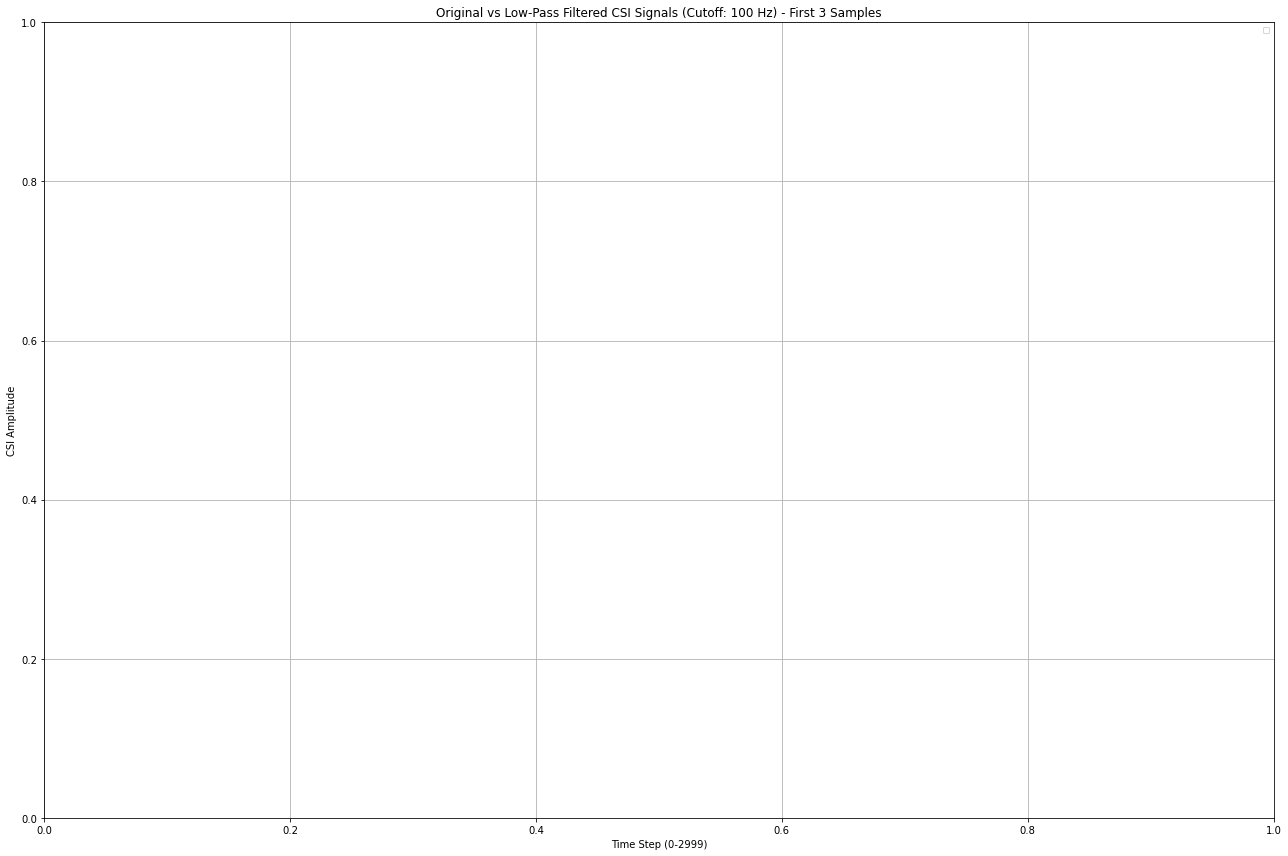

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

# Ensure data_x is available from previous cells.
# data_x shape: (num_samples, 3000, 3, 3, 30)

if 'data_x' not in locals():
    print("Error: data_x is not defined. Please ensure it is loaded in a previous cell.")
else:
    print(f"Shape of data_x: {data_x.shape}")
    num_samples_to_plot = 3
    if data_x.shape[0] < num_samples_to_plot:
        print(f"Warning: Requested {num_samples_to_plot} samples, but data_x only has {data_x.shape[0]} samples. Plotting all available samples.")
        num_samples_to_plot = data_x.shape[0]

    if num_samples_to_plot > 0:
        # Filter parameters
        sampling_rate = 1000  # Hz
        cutoff_frequency = 100  # Hz
        nyquist_frequency = 0.5 * sampling_rate
        normalized_cutoff = cutoff_frequency / nyquist_frequency
        filter_order = 4  # Order of the Butterworth filter

        # Design the Butterworth low-pass filter
        b, a = butter(filter_order, normalized_cutoff, btype='low', analog=False)

        # Determine the number of subplots needed (2 plots per sample: original and filtered)
        # For better readability, let's plot each sample in its own subplot, showing original vs filtered.
        # Or, to keep it on one plot as originally, we can use different line styles or colors.
        # Let's try plotting original and filtered for each sample on the *same* main plot, but ensure labels are clear.
        plt.figure(figsize=(18, 12)) # Increased height for better legend visibility if many lines
        
        for i in range(400, num_samples_to_plot):
            # Extract the time-domain signal for the i-th sample
            signal = data_x[i, :, 0, 0, 0]
            print(f"Signal label: {y[i]}")
            # Apply the low-pass filter
            filtered_signal = filtfilt(b, a, signal)
            
            # Plot original signal
            plt.plot(signal, label=f'Original Sample {i}', alpha=0.6, linestyle=':')
            
            # Plot filtered signal
            plt.plot(filtered_signal, label=f'Filtered Sample {i}', alpha=0.9)
        
        plt.title(f'Original vs Low-Pass Filtered CSI Signals (Cutoff: {cutoff_frequency} Hz) - First {num_samples_to_plot} Samples')
        plt.xlabel('Time Step (0-2999)')
        plt.ylabel('CSI Amplitude')
        # Adjust legend to handle potentially many lines
        if num_samples_to_plot <= 5: # Show full legend if not too cluttered
            plt.legend(loc='upper right', fontsize='small')
        else: # Otherwise, indicate that legend might be too large
            plt.legend(title=f'{num_samples_to_plot*2} lines, legend may be cluttered', loc='upper right', fontsize='x-small')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No samples available in data_x to plot.")